In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define the partition function approximation
def partition_function(tau2, d, mass_levels, coeffs):
    """
    Compute an approximation to Z_string including massless and massive terms.

    tau2: The imaginary part of the modular parameter tau
    d: Number of non-compact dimensions
    mass_levels: List of mass levels m+n for string states
    coeffs: Coefficients a_{m,n} for the corresponding mass levels
    """
    # Massless term (moderate decay)
    Z_massless = tau2**(1 - d/2)

    # Massive terms (exponential suppression)
    Z_massive = sum(c * np.exp(-2 * np.pi * (m + n) * tau2) for (m, n), c in zip(mass_levels, coeffs))

    return Z_massless + Z_massive

# Define parameters
tau2_values = np.linspace(1, 10, 100)  # Range of tau2 values
d = 10  # Typical number of non-compact dimensions in superstring theory

# Define some mass levels (m+n) and their coefficients
mass_levels = [(1, 1), (2, 2), (3, 3), (4, 4)]
coeffs = [1.0, 0.5, 0.2, 0.1]  # Arbitrary example coefficients

# Compute Z_string for different tau2 values
Z_values = np.array([partition_function(t, d, mass_levels, coeffs) for t in tau2_values])


In [6]:
# Attempting an alternative method to generate and display the plot

import numpy as np
import matplotlib.pyplot as plt

# Define the partition function approximation
def partition_function(tau2, d, mass_levels, coeffs):
    """
    Compute an approximation to Z_string including massless and massive terms.

    tau2: The imaginary part of the modular parameter tau
    d: Number of non-compact dimensions
    mass_levels: List of mass levels (m, n) for string states
    coeffs: Coefficients a_{m,n} for the corresponding mass levels
    """
    # Massless term (moderate decay)
    Z_massless = tau2**(1 - d/2)

    # Massive terms (exponential suppression)
    Z_massive = sum(c * np.exp(-2 * np.pi * (m + n) * tau2) for (m, n), c in zip(mass_levels, coeffs))

    return Z_massless + Z_massive

# Define parameters
tau2_values = np.linspace(1, 10, 100)  # Range of tau2 values
d = 10  # Number of non-compact dimensions in superstring theory

# Define some mass levels (m, n) and their coefficients
mass_levels = [(1, 1), (2, 2), (3, 3), (4, 4)]
coeffs = [1.0, 0.5, 0.2, 0.1]  # Example coefficients

# Compute Z_string for different tau2 values
Z_values = np.array([partition_function(t, d, mass_levels, coeffs) for t in tau2_values])
massless_values = tau2_values**(1 - d/2)

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tau2_values, Z_values, label=r"$\mathcal{Z}_{\text{string}}(\tau_2)$", color='b')
ax.plot(tau2_values, massless_values, '--', label=r"$\tau_2^{1 - d/2}$ (Massless Term)", color='r')

ax.set_yscale("log")  # Log scale to see the behavior clearly
ax.set_xlabel(r"$\tau_2$")
ax.set_ylabel(r"$\mathcal{Z}_{\text{string}}$")
ax.set_title("Decay of String Partition Function at Large $\tau_2$")
ax.legend()
ax.grid(True)

# Display the plot
plt.show()


ValueError: 
\mathcal{Z}_{\text{string}}
             ^
ParseSyntaxException: Unknown symbol: \text, found '\'  (at char 13), (line:1, col:14)

<Figure size 800x500 with 1 Axes>

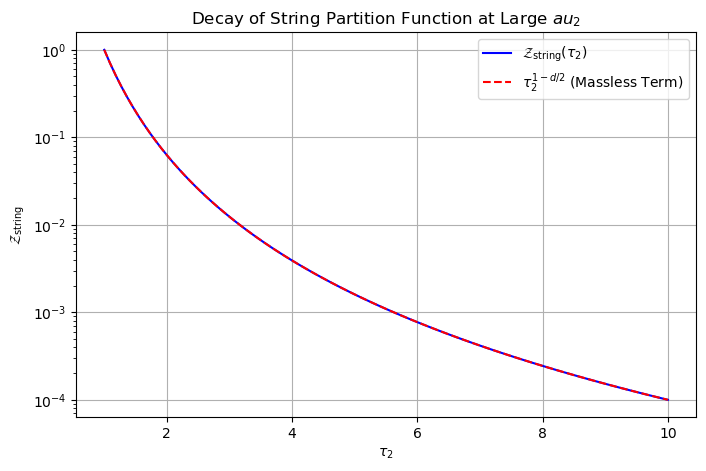

In [8]:
# Debugging version of the partition function computation

import numpy as np
import matplotlib.pyplot as plt

# Define the partition function approximation with error handling
def partition_function(tau2, d, mass_levels, coeffs):
    """
    Compute an approximation to Z_string including massless and massive terms with error handling.

    tau2: The imaginary part of the modular parameter tau
    d: Number of non-compact dimensions
    mass_levels: List of mass levels (m, n) for string states
    coeffs: Coefficients a_{m,n} for the corresponding mass levels
    """
    if tau2 <= 0:
        raise ValueError("tau2 must be positive to avoid numerical instability.")

    # Massless term (moderate decay)
    try:
        Z_massless = tau2**(1 - d/2)
    except Exception as e:
        print(f"Error computing massless term: {e}")
        Z_massless = 0

    # Massive terms (exponential suppression)
    Z_massive = 0
    for (m, n), c in zip(mass_levels, coeffs):
        try:
            Z_massive += c * np.exp(-2 * np.pi * (m + n) * tau2)
        except Exception as e:
            print(f"Error computing massive term for (m={m}, n={n}): {e}")
            Z_massive += 0  # Fallback to zero if an issue occurs

    return Z_massless + Z_massive

# Define parameters
tau2_values = np.linspace(1, 10, 100)  # Range of tau2 values (avoiding zero)
d = 10  # Typical number of non-compact dimensions in superstring theory

# Define some mass levels (m, n) and their coefficients
mass_levels = [(1, 1), (2, 2), (3, 3), (4, 4)]
coeffs = [1.0, 0.5, 0.2, 0.1]  # Example coefficients

# Compute Z_string for different tau2 values with error checking
Z_values = []
for t in tau2_values:
    try:
        Z_values.append(partition_function(t, d, mass_levels, coeffs))
    except Exception as e:
        print(f"Error at tau2={t}: {e}")
        Z_values.append(np.nan)  # Assign NaN if computation fails

Z_values = np.array(Z_values)
massless_values = tau2_values**(1 - d/2)

# Plot results with safe handling
plt.figure(figsize=(8, 5))
plt.plot(tau2_values, Z_values, label=r"$\mathcal{Z}_{\mathrm{string}}(\tau_2)$", color='b')
plt.plot(tau2_values, massless_values, '--', label=r"$\tau_2^{1 - d/2}$ (Massless Term)", color='r')

plt.yscale("log")  # Log scale to highlight behavior
plt.xlabel(r"$\tau_2$")
plt.ylabel(r"$\mathcal{Z}_{\mathrm{string}}$")
plt.title("Decay of String Partition Function at Large $\tau_2$")
plt.legend()
plt.grid(True)
plt.show()


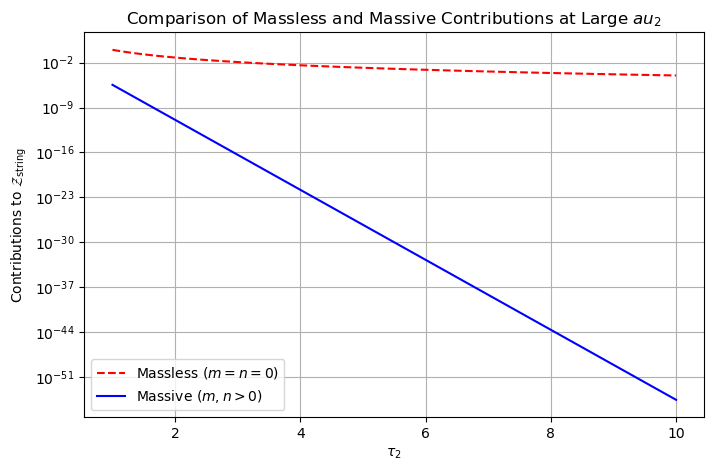

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define the partition function with separate massless and massive contributions
def partition_function_components(tau2, d, mass_levels, coeffs):
    """
    Compute separate contributions to Z_string: massless and massive terms.

    tau2: The imaginary part of the modular parameter tau
    d: Number of non-compact dimensions
    mass_levels: List of mass levels (m, n) for string states
    coeffs: Coefficients a_{m,n} for the corresponding mass levels
    """
    # Massless term (moderate decay, no exponential suppression)
    Z_massless = tau2**(1 - d/2)

    # Massive terms (exponential suppression)
    Z_massive = sum(c * np.exp(-2 * np.pi * (m + n) * tau2) for (m, n), c in zip(mass_levels, coeffs))

    return Z_massless, Z_massive

# Define parameters
tau2_values = np.linspace(1, 10, 100)  # Range of tau2 values
d = 10  # Number of non-compact dimensions in superstring theory

# Define some mass levels (m, n) and their coefficients
mass_levels = [(1, 1), (2, 2), (3, 3), (4, 4)]
coeffs = [1.0, 0.5, 0.2, 0.1]  # Example coefficients

# Compute separate contributions for different tau2 values
Z_massless_values = []
Z_massive_values = []
for t in tau2_values:
    Z_m0, Z_mpos = partition_function_components(t, d, mass_levels, coeffs)
    Z_massless_values.append(Z_m0)
    Z_massive_values.append(Z_mpos)

# Convert lists to arrays for plotting
Z_massless_values = np.array(Z_massless_values)
Z_massive_values = np.array(Z_massive_values)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(tau2_values, Z_massless_values, '--', label=r"Massless ($m=n=0$)", color='r')
plt.plot(tau2_values, Z_massive_values, label=r"Massive ($m, n > 0$)", color='b')

plt.yscale("log")  # Log scale to highlight behavior
plt.xlabel(r"$\tau_2$")
plt.ylabel(r"Contributions to $\mathcal{Z}_{\mathrm{string}}$")
plt.title("Comparison of Massless and Massive Contributions at Large $\tau_2$")
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


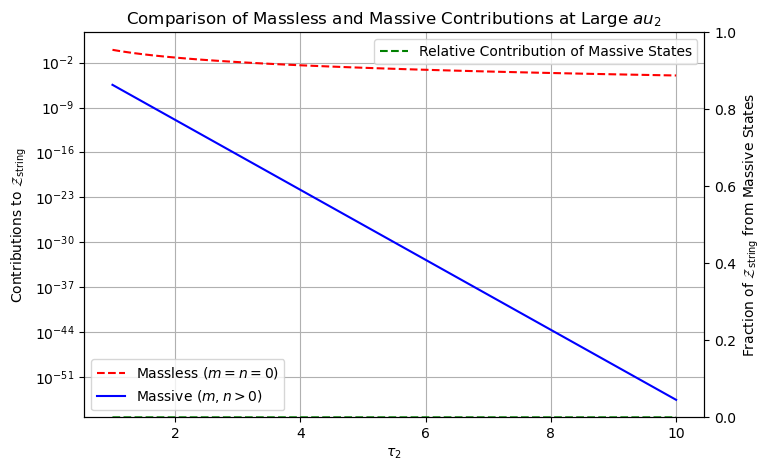

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Define the partition function components with massless and massive terms
def partition_function_components(tau2, d, mass_levels, coeffs):
    """
    Compute separate contributions to Z_string: massless and massive terms.

    tau2: The imaginary part of the modular parameter tau
    d: Number of non-compact dimensions
    mass_levels: List of mass levels (m, n) for string states
    coeffs: Coefficients a_{m,n} for the corresponding mass levels
    """
    # Massless term (moderate decay, power-law behavior)
    Z_massless = tau2**(1 - d/2)

    # Massive terms (exponential suppression)
    Z_massive = sum(c * np.exp(-2 * np.pi * (m + n) * tau2) for (m, n), c in zip(mass_levels, coeffs))

    return Z_massless, Z_massive

# Define parameters
tau2_values = np.linspace(1, 10, 100)  # Range of tau2 values
d = 10  # Number of non-compact dimensions in superstring theory

# Define some mass levels (m, n) and their coefficients
mass_levels = [(1, 1), (2, 2), (3, 3), (4, 4)]  # Representative higher-energy states
coeffs = [1.0, 0.5, 0.2, 0.1]  # Example coefficients

# Compute separate contributions for different tau2 values
Z_massless_values = []
Z_massive_values = []
relative_massive_contribution = []
for t in tau2_values:
    Z_m0, Z_mpos = partition_function_components(t, d, mass_levels, coeffs)
    Z_massless_values.append(Z_m0)
    Z_massive_values.append(Z_mpos)
    if (Z_m0 + Z_mpos) > 0:
        relative_massive_contribution.append(Z_mpos / (Z_m0 + Z_mpos))
    else:
        relative_massive_contribution.append(0)  # Avoid division by zero

# Convert lists to arrays for plotting
Z_massless_values = np.array(Z_massless_values)
Z_massive_values = np.array(Z_massive_values)
relative_massive_contribution = np.array(relative_massive_contribution)

# Plot the absolute contributions of massless and massive terms
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(tau2_values, Z_massless_values, '--', label=r"Massless ($m=n=0$)", color='r')
ax1.plot(tau2_values, Z_massive_values, label=r"Massive ($m, n > 0$)", color='b')

ax1.set_yscale("log")  # Log scale to highlight behavior
ax1.set_xlabel(r"$\tau_2$")
ax1.set_ylabel(r"Contributions to $\mathcal{Z}_{\mathrm{string}}$")
ax1.set_title("Comparison of Massless and Massive Contributions at Large $\tau_2$")
ax1.legend()
ax1.grid(True)

# Create a second y-axis for the relative contribution of massive terms
ax2 = ax1.twinx()
ax2.plot(tau2_values, relative_massive_contribution, 'g--', label="Relative Contribution of Massive States")
ax2.set_ylabel("Fraction of $\mathcal{Z}_{\mathrm{string}}$ from Massive States")
ax2.set_ylim(0, 1)
ax2.legend(loc="upper right")

# Display the plot
plt.show()

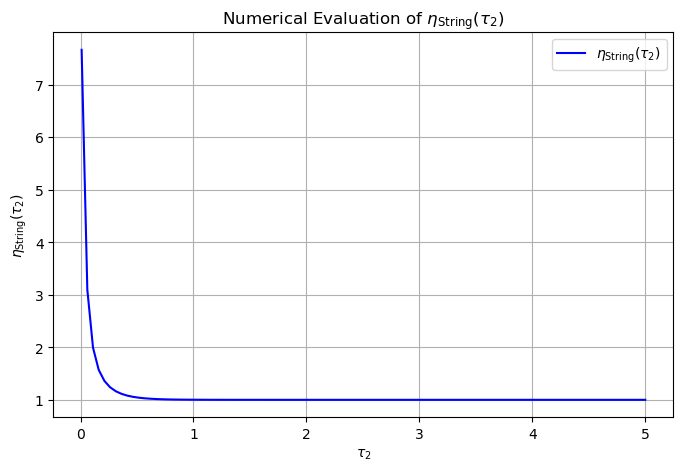

In [14]:
# Correcting LaTeX syntax issue in plot labels

# Define parameters for numerical evaluation
tau2_values = np.linspace(0.01, 5, 100)  # Range of tau2 values
rho_values = np.arange(1, 10)  # Example spectral values for summation

# Define the damping function eta_String
def eta_string(tau2, rho_values):
    return 1 + np.sum([np.exp(-2 * np.pi * rho * tau2) for rho in rho_values], axis=0)

# Compute eta_String for the given tau2 values
eta_values = np.array([eta_string(tau2, rho_values) for tau2 in tau2_values])

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(tau2_values, eta_values, label=r'$\eta_{\mathrm{String}}(\tau_2)$', color='b')
plt.xlabel(r'$\tau_2$')
plt.ylabel(r'$\eta_{\mathrm{String}}(\tau_2)$')
plt.title(r'Numerical Evaluation of $\eta_{\mathrm{String}}(\tau_2)$')
plt.legend()
plt.grid()
plt.show()
